# Online Retail Exploratory Data Analysis

## Objective

The objective of this notebook is to analyze online retail transactions, identify sales trends, evaluate product and customer performance, and generate actionable business insights through exploratory data analysis and customer segmentation.

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [133]:
df = pd.read_csv('/content/online_retail_cleaned1.csv')

In [134]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Country'] = df['Country'].astype('category')
df['RecordType'] = df['RecordType'].astype('category')
df['Description'] = df['Description'].astype('category')
df['CustomerID'] = df['CustomerID'].astype('Int64')

# Revenue Analysis

The objective of this section is to evaluate overall business revenue, quantify the impact of returns, and establish key performance indicators for subsequent analysis.

In [135]:
df['Revenue'] = df['Quantity']*df['UnitPrice']

In [136]:
net_revenue = df['Revenue'].sum()
print(f"Net Revenue: £{net_revenue:,.2f}")

Net Revenue: £9,726,006.95


In [137]:
returns_revenue = df[df['Revenue']<0]['Revenue'].sum()
print(f"Returns Revenue: £{abs(returns_revenue):,.2f}")

Returns Revenue: £916,103.85


In [138]:
return_rate = (abs(returns_revenue)/net_revenue)*100
print(f"Return Rate: {return_rate:.2f}%")

Return Rate: 9.42%


In [139]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.month_name()
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

In [140]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

###Insights
Net Revenue amounted to £10.64M, while returns and cancellations accounted for £916K (9.42% of gross sales), resulting in a net revenue of £9.73M.

# Time Analysis section

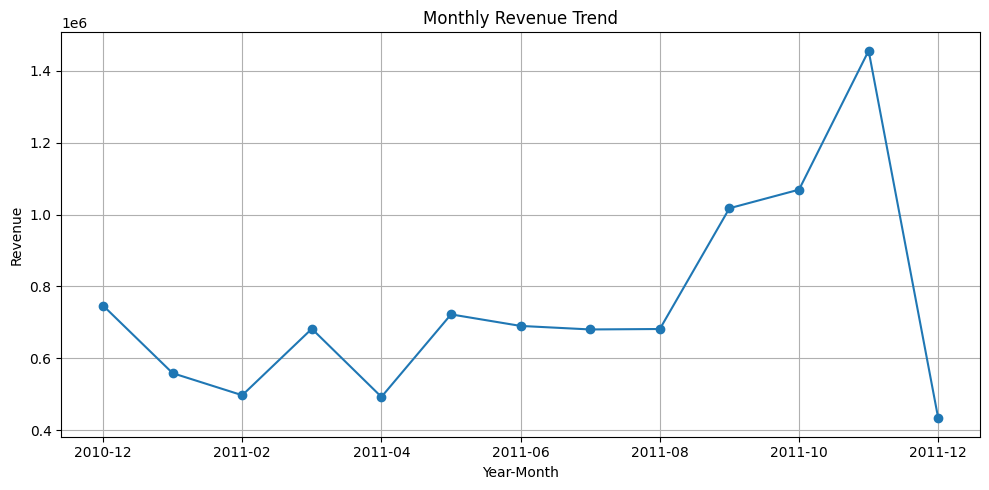

In [141]:
monthly_rev = df.groupby(df['YearMonth'].astype(str))['Revenue'].sum()

monthly_rev.plot(
    kind='line',
    marker='o',
    figsize=(10,5),
    grid=True,
    title='Monthly Revenue Trend'
)

plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Monthly Revenue Trend Analysis

#### 1. Which month generated the highest revenue?

**November 2011** generated the highest revenue, with total revenue of approximately **£1.46 million**. This was the peak revenue month in the entire dataset.

---

#### 2. Which month generated the lowest revenue?

The month with the lowest revenue overall was **December 2011**, with revenue of approximately **£0.43 million**. However, this month contains data only up to **9 December 2011** and is therefore not directly comparable to the other months.

Excluding the incomplete December 2011 data, **April 2011** generated the lowest revenue, with approximately **£0.49 million** in sales.

---

#### 3. What is the overall trend?

The overall revenue trend is **upward**. Revenue remained relatively stable between **December 2010 and August 2011**, generally ranging from **£0.5 million to £0.75 million**. From **September 2011 onwards**, revenue increased significantly, reaching its highest point in **November 2011**.

---

#### 4. Is there evidence of seasonality?

Yes, the data shows a clear seasonal pattern. Revenue increased substantially during the final quarter of the year, particularly between **September and November 2011**.

- September 2011: ~£1.02 million
- October 2011: ~£1.07 million
- November 2011: ~£1.46 million

This suggests that customer spending intensified towards the end of the year, likely due to holiday and festive-season shopping.

---

#### 5. Are there any unusual spikes or drops?

**Major Spike:**
- November 2011 recorded an exceptional increase in revenue compared to previous months and was the strongest-performing month in the dataset.

**Major Drop:**
- December 2011 shows a sharp decline in revenue. However, this is due to the dataset containing transactions only up to **9 December 2011**, rather than an actual decrease in business performance.

---

#### 6. Business Insight

Revenue remained relatively stable during the first eight months of 2011 before increasing sharply from September onwards. The business achieved its highest revenue in **November 2011**, indicating a strong seasonal effect and increased customer purchasing activity during the final quarter of the year. The decline observed in December 2011 should not be interpreted as reduced business performance because the month contains incomplete data.

---

### Key Finding

The business experiences its strongest sales performance during the final quarter (**Q4**), particularly in **November**. Seasonal demand appears to be a major contributor to revenue growth, making the end-of-year period the most important sales season for the business.

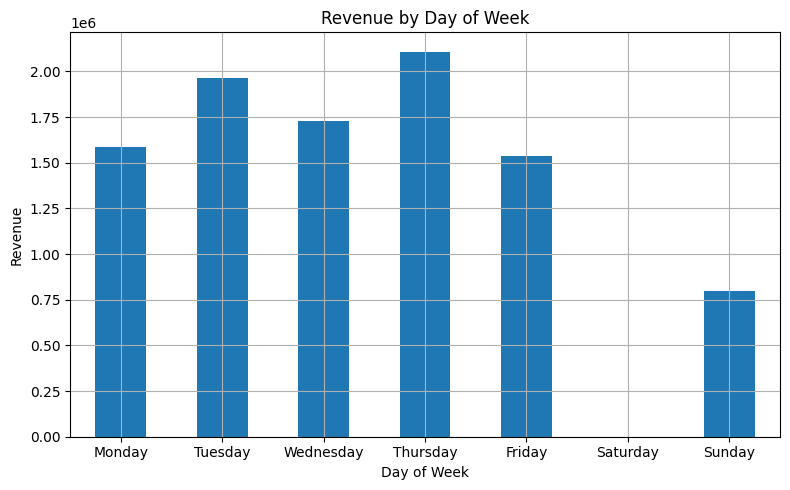

In [142]:
day_rev = df.groupby('DayOfWeek')['Revenue'].sum()

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_rev = day_rev.reindex(day_order)

day_rev.plot(
    kind='bar',
    figsize=(8,5),
    grid=True,
    title='Revenue by Day of Week'
)

plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Revenue by Day of Week Analysis

#### 1. Which day generates the highest revenue?

**Thursday** generates the highest revenue, with approximately **£2.1 million** in total sales. This makes Thursday the strongest-performing day of the week.

---

#### 2. Which day generates the lowest revenue?

**Sunday** generates the lowest revenue, with approximately **£0.8 million** in total sales. Customer spending is noticeably lower on Sundays compared to the rest of the week.

---

#### 3. Is revenue evenly distributed across the week?

No, revenue is not evenly distributed throughout the week. Significant variations can be observed across different days, indicating that customer purchasing behavior changes depending on the day of the week.

---

#### 4. Which days form the strongest sales period?

The strongest sales period occurs during the middle of the week, particularly on:

- Tuesday
- Wednesday
- Thursday

These days consistently generate the highest revenue and represent the peak purchasing period for the business.

---

#### 5. Is there any unusual pattern?

Yes, two notable patterns can be observed:

- No transactions were recorded on **Saturday**, indicating that the business did not operate or record transactions on that day.
- Revenue drops substantially on **Sunday** compared to weekdays, suggesting reduced customer activity during weekends.

---

#### 6. Business Insight

Revenue is concentrated during the middle and latter part of the workweek, with **Thursday** emerging as the highest-performing day. Customer spending declines significantly on **Sunday**, and no sales activity is recorded on **Saturday**. This suggests that customers primarily make purchases during business days, making **Tuesday through Thursday** the most effective period for promotions, marketing campaigns, and inventory planning.

---

### Key Finding

Customer purchasing activity is strongest during the middle of the week, particularly on **Thursday**, while weekends contribute significantly less revenue. The absence of Saturday transactions indicates a unique operational pattern within the business.

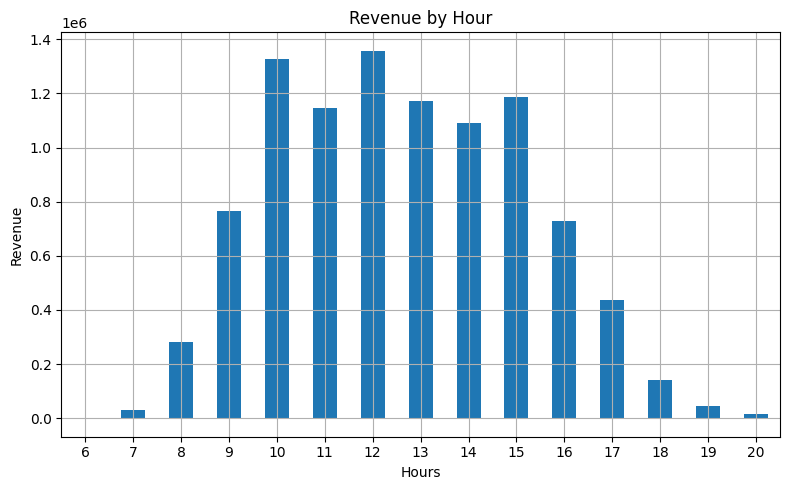

In [143]:
hour_rev = df.groupby('Hour')['Revenue'].sum()

hour_rev.plot(
    kind='bar',
    figsize=(8,5),
    grid=True,
    title='Revenue by Hour'
)

plt.xlabel('Hours')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Revenue by Hour Analysis

#### 1. Which hour generates the highest revenue?

**12 PM (Hour = 12)** generates the highest revenue, with approximately **£1.36 million** in sales. This represents the peak purchasing hour in the dataset.

---

#### 2. Which hour generates the lowest revenue?

**6 AM (Hour = 6)** generates the lowest revenue. Very little purchasing activity occurs during the earliest hours of the day.

---

#### 3. During which time window does most purchasing activity occur?

The highest revenue is concentrated between **10 AM and 3 PM**. During this period, hourly revenue consistently exceeds **£1 million**, indicating that most customer spending occurs during midday and early afternoon hours.

---

#### 4. Is customer spending concentrated or spread throughout the day?

Customer spending is highly concentrated during business hours. Revenue increases rapidly during the morning, remains consistently high from **10 AM to 3 PM**, and then gradually declines throughout the evening.

---

#### 5. Are there any unusual spikes or drops?

**Major Spike:**
- Revenue reaches its maximum at **12 PM**, suggesting strong midday purchasing activity.

**Major Drop:**
- Revenue declines substantially after **4 PM** and becomes very low after **6 PM**, indicating limited evening purchasing activity.

---

#### 6. Business Insight

Customer purchasing activity is concentrated during standard business hours, particularly between **10 AM and 3 PM**. The strongest sales performance occurs around **midday**, making this period ideal for promotions, product launches, and marketing campaigns. Since revenue drops significantly during evening hours, resources and staffing can be prioritized during peak daytime periods.

---

### Key Finding

The business experiences its highest customer spending during midday hours, with **12 PM** emerging as the peak revenue hour. Most sales occur between **10 AM and 3 PM**, while purchasing activity declines sharply during the evening.

# Country Analysis Section

/tmp/ipykernel_3722/1875181874.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Country')['Revenue']


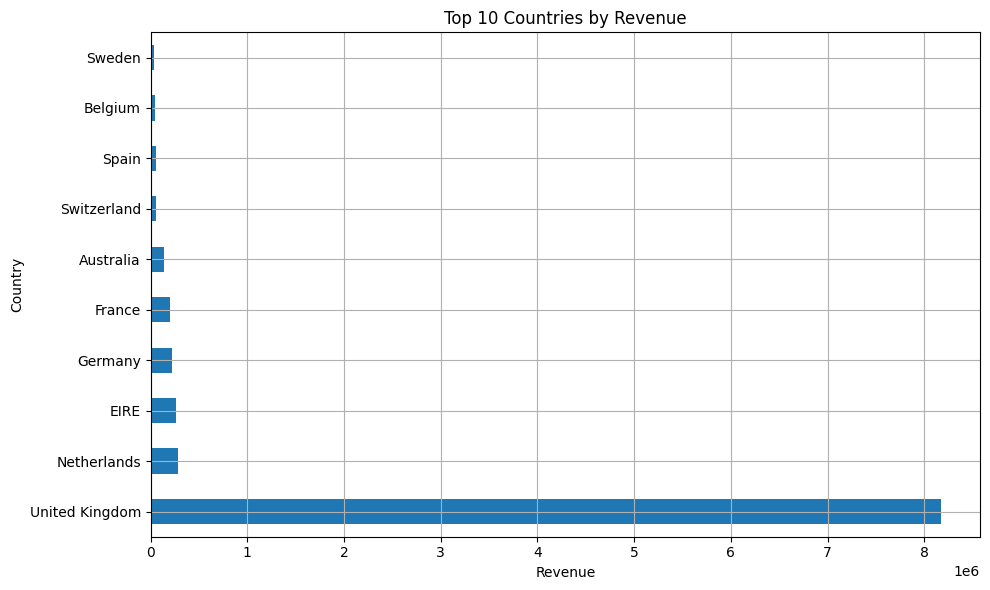

In [144]:
country_rev = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_rev.plot(
    kind='barh',
    figsize=(10,6),
    grid=True,
    title='Top 10 Countries by Revenue'
)

plt.xlabel('Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [145]:
country_rev = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
)

country_rev_no_uk = country_rev[country_rev.index != 'United Kingdom']

/tmp/ipykernel_3722/711247302.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Country')['Revenue']


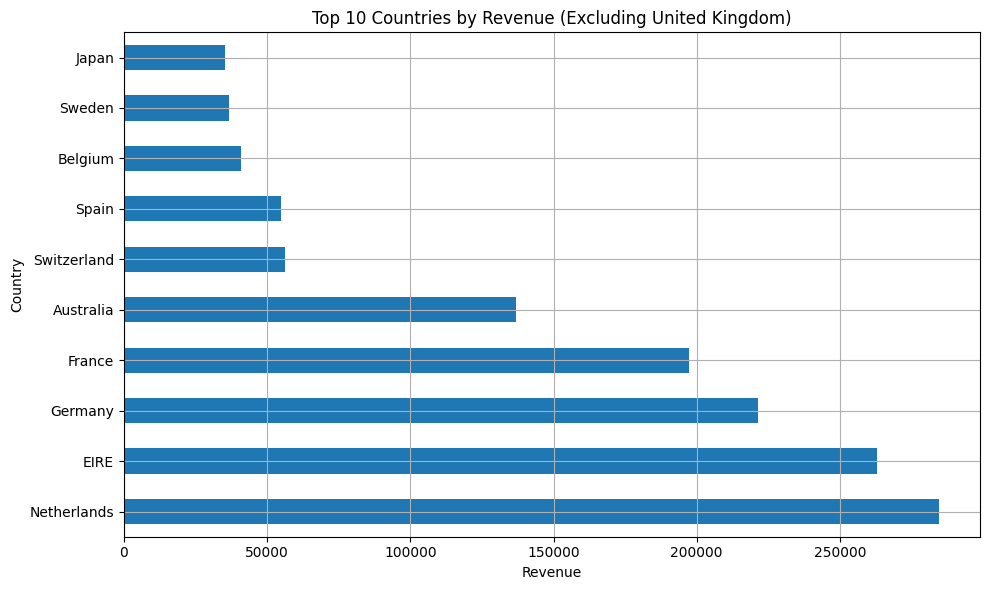

In [146]:
country_rev_no_uk.head(10).plot(
    kind='barh',
    figsize=(10,6),
    grid=True,
    title='Top 10 Countries by Revenue (Excluding United Kingdom)'
)

plt.xlabel('Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Revenue by Country Analysis

#### 1. Which country generates the highest revenue?

The **United Kingdom** generates the highest revenue, contributing approximately **£8.18 million** in sales. It is by far the largest market in the dataset.

---

#### 2. Which country generates the highest revenue outside the United Kingdom?

Excluding the United Kingdom, the **Netherlands** generates the highest revenue, with approximately **£285,000** in sales.

---

#### 3. Which country generates the lowest revenue among the top international markets?

Among the top 10 countries excluding the United Kingdom, **Japan** generates the lowest revenue, contributing approximately **£35,000**.

---

#### 4. Does one country dominate the business?

Yes. The business is heavily dominated by the **United Kingdom**, which contributes the majority of total revenue. Revenue from the UK is significantly higher than that of all other countries combined.

---

#### 5. Which countries are the strongest international markets?

The strongest international markets are:

1. Netherlands
2. EIRE (Ireland)
3. Germany
4. France
5. Australia

These countries contribute the highest revenue outside the United Kingdom and represent the most important international customer bases.

---

#### 6. Is revenue evenly distributed across countries?

No. Revenue is highly concentrated in a small number of countries. While the United Kingdom dominates overall sales, only a few international markets contribute meaningful revenue, with many countries generating relatively small amounts.

---

#### 7. Business Insight

The United Kingdom is the company's primary revenue source and represents its core market. Among international markets, the Netherlands, EIRE, Germany, France, and Australia show the strongest performance and may offer the greatest opportunities for international growth. Marketing, logistics, and expansion efforts should be prioritized in these high-performing regions.

---

### Key Finding

The business is highly dependent on the **United Kingdom** for revenue generation. However, several international markets, particularly the **Netherlands** and **EIRE**, demonstrate strong performance and represent valuable opportunities for future expansion.

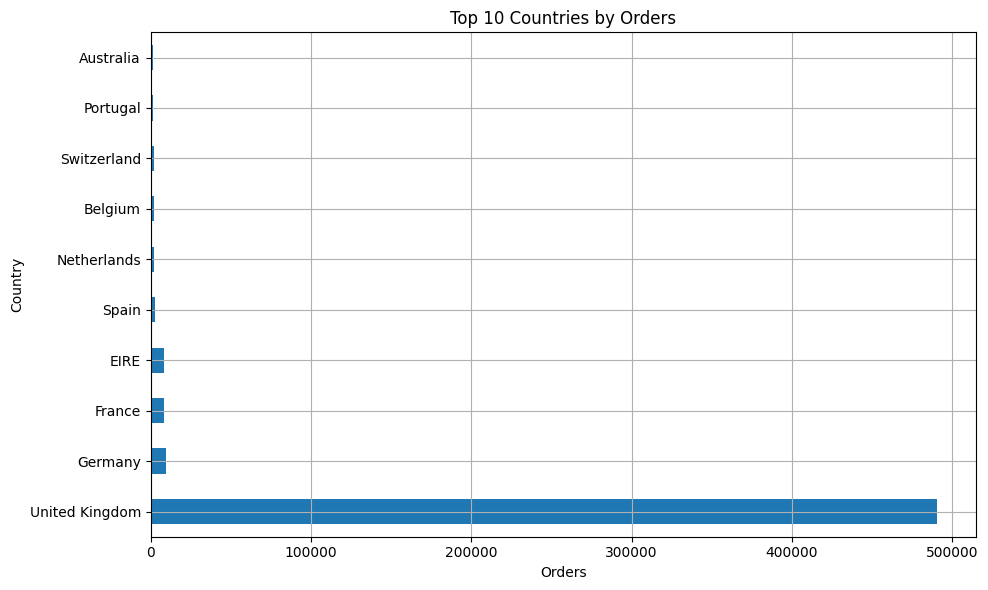

In [147]:
top_10_country_orders = (
    df['Country']
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
)

top_10_country_orders.plot(
    kind='barh',
    figsize=(10,6),
    grid=True,
    title='Top 10 Countries by Orders'
)

plt.xlabel('Orders')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

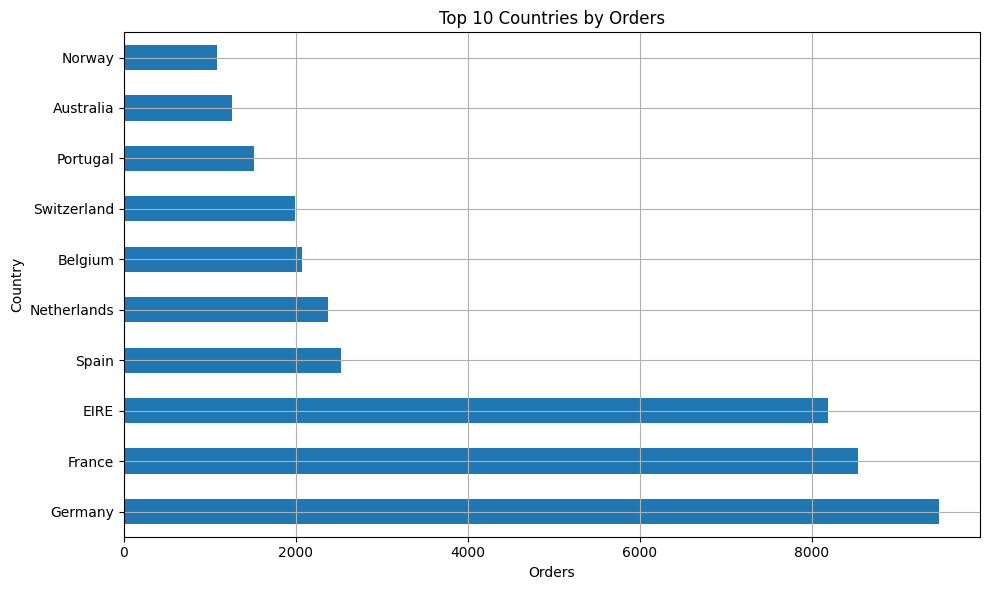

In [148]:
country_ord_no_uk = (
    df[df['Country'] != 'United Kingdom']['Country']
    .value_counts()
    .head(10)
)
country_ord_no_uk.plot(
    kind='barh',
    figsize=(10,6),
    grid=True,
    title='Top 10 Countries by Orders'
)

plt.xlabel('Orders')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Orders by Country Analysis (Excluding United Kingdom)

#### 1. Which country places the most orders?

Excluding the United Kingdom, **Germany** places the highest number of orders, with approximately **9,480 orders**. This indicates a highly active customer base.

---

#### 2. Which countries follow Germany in order volume?

The next highest-order countries are:

1. France
2. EIRE (Ireland)

Together with Germany, these countries represent the most active international markets in terms of purchasing frequency.

---

#### 3. Does the ranking differ from the revenue ranking?

Yes. The order-volume ranking differs noticeably from the revenue ranking.

**Revenue Ranking (excluding UK):**
1. Netherlands
2. EIRE
3. Germany
4. France
5. Australia

**Order Ranking (excluding UK):**
1. Germany
2. France
3. EIRE
4. Spain
5. Netherlands

This indicates that countries generating the most revenue are not necessarily placing the most orders.

---

#### 4. Which countries appear to have higher-value orders?

The **Netherlands** appears to have the highest-value orders. Although it ranks only fifth in order count, it generates the highest international revenue. This suggests that Dutch customers spend substantially more per order.

Australia shows a similar pattern, generating relatively high revenue despite a lower order count.

---

#### 5. Which countries appear to have lower-value orders?

Germany and France place a large number of orders but rank lower in revenue generation. This suggests that customers in these countries tend to place smaller-value orders on average.

---

#### 6. Business Insight

International customer behavior varies significantly across countries. Germany and France represent high-frequency purchasing markets, while the Netherlands appears to be a high-value market where customers spend more per transaction. Different sales and marketing strategies may therefore be required for different regions.

---

### Key Finding

Order volume and revenue do not follow the same pattern across countries. While Germany leads in purchasing frequency, the Netherlands generates the highest international revenue, indicating substantially higher average order values.

# Product Analysis Section

Investigation of top revenue-generating descriptions revealed the presence of non-merchandise records, including postage charges, bank charges, and gift vouchers. These records were excluded from product-level revenue analysis to ensure rankings reflected actual merchandise performance rather than service-related or financial transactions.

/tmp/ipykernel_3722/4257451903.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_10_product_rev = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)


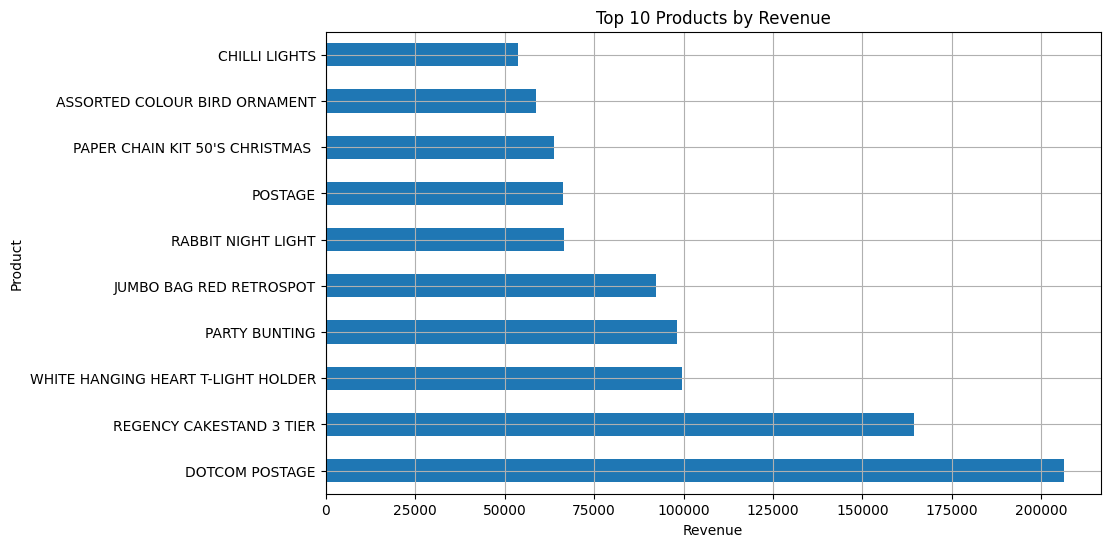

In [149]:
top_10_product_rev = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_10_product_rev.plot(
    kind='barh',
    grid=True,
    figsize=(10,6)
)
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Top 10 Products by Revenue')
plt.show()

In [150]:
df_filtered = df[
    (df['Description'] != 'DOTCOM POSTAGE') &
    (df['Description'] != 'POSTAGE') &
    (df['Description'] != 'Bank Charges') &
    (~df['Description'].str.contains('Gift Voucher', case=False, na=False))
]

In [151]:
top_10_product_rev = df_filtered.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

/tmp/ipykernel_3722/2857085636.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_10_product_rev = df_filtered.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)


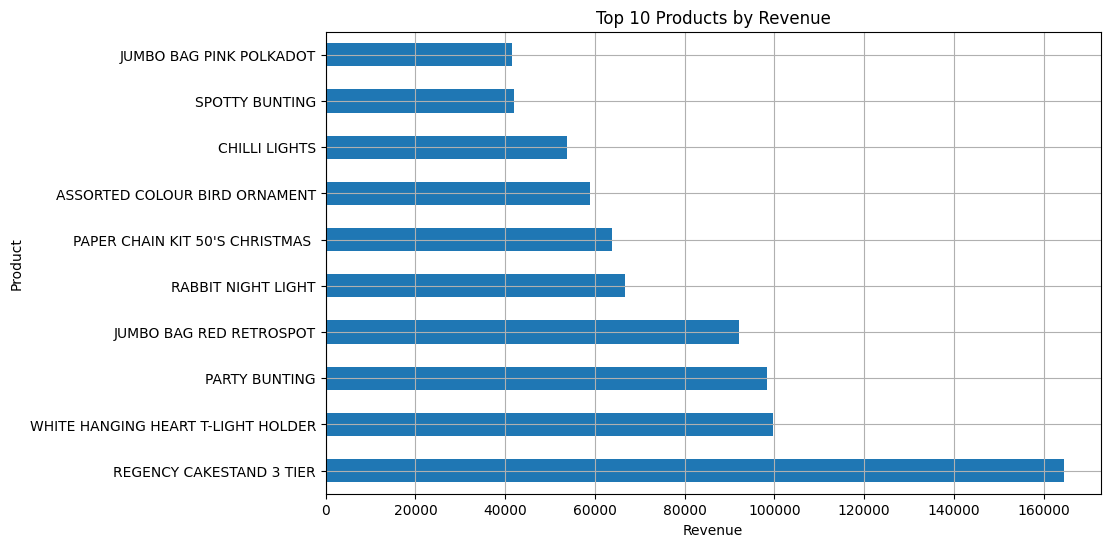

In [152]:
top_10_product_rev.plot(
    kind='barh',
    grid=True,
    figsize=(10,6)
)
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Top 10 Products by Revenue')
plt.show()

### Top Products by Revenue Analysis

#### 1. Which product generates the highest revenue?

**REGENCY CAKESTAND 3 TIER** is the highest revenue-generating product, contributing approximately **£164,000** in revenue. It significantly outperforms all other merchandise products in the dataset.

---

#### 2. Which products follow the top performer?

The next highest revenue-generating products are:

1. WHITE HANGING HEART T-LIGHT HOLDER
2. PARTY BUNTING
3. JUMBO BAG RED RETROSPOT

Each of these products generates close to or above **£90,000** in revenue.

---

#### 3. Are there any common characteristics among the top products?

Yes. Most of the top-performing products belong to categories such as:

- Home décor
- Party decorations
- Gift items
- Household accessories

This suggests that decorative and gifting products represent an important revenue source for the business.

---

#### 4. Is revenue evenly distributed across products?

No. Revenue is concentrated among a relatively small number of products. The top-performing products contribute substantially more revenue than the majority of products in the catalog.

---

#### 5. Business Insight

The business derives a significant portion of its revenue from decorative and gift-oriented merchandise. Products such as cake stands, decorative lighting, ornaments, and party accessories consistently generate high revenue and should be prioritized for inventory management, marketing campaigns, and promotional activities.

---

### Key Finding

**REGENCY CAKESTAND 3 TIER** is the strongest-performing merchandise product in the dataset. The revenue rankings indicate that home décor, gifting, and party-related products form the core of the retailer's product portfolio and are major contributors to overall sales performance.

# Quantity Analysis Section

In [153]:
top_10_product_quan = df_filtered.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

/tmp/ipykernel_3722/352334696.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_10_product_quan = df_filtered.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)


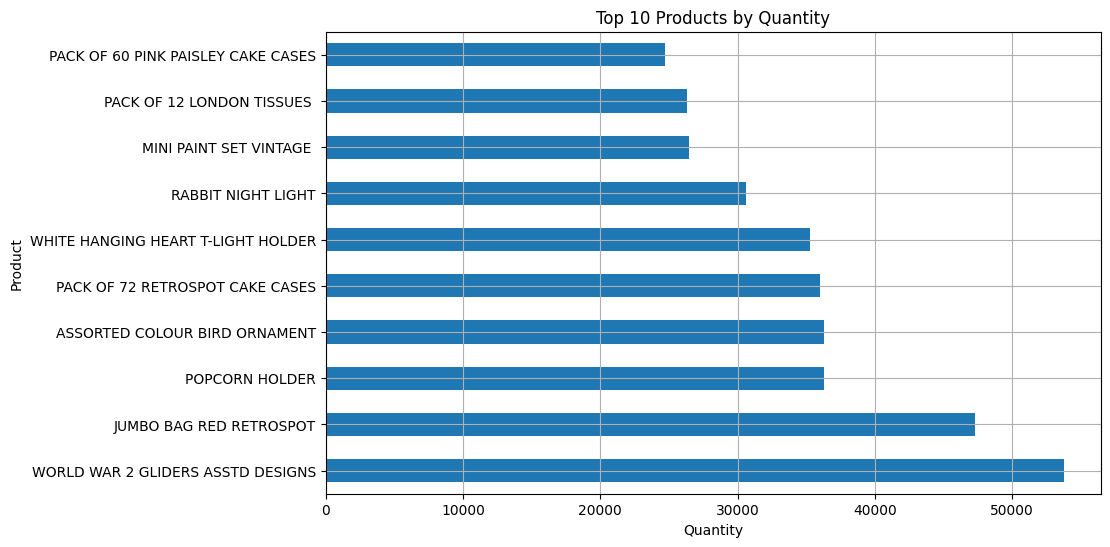

In [154]:
top_10_product_quan.plot(
    kind='barh',
    grid=True,
    figsize=(10,6)
)
plt.xlabel('Quantity')
plt.ylabel('Product')
plt.title('Top 10 Products by Quantity')
plt.show()

### Top Products by Quantity Sold Analysis

#### 1. Which product sold the highest quantity?

**WORLD WAR 2 GLIDERS ASSTD DESIGNS** is the most purchased product in the dataset, with approximately **53,751 units sold**.

---

#### 2. Which products follow the top performer?

Other highly purchased products include:

1. JUMBO BAG RED RETROSPOT
2. POPCORN HOLDER
3. ASSORTED COLOUR BIRD ORNAMENT
4. PACK OF 72 RETROSPOT CAKE CASES
5. WHITE HANGING HEART T-LIGHT HOLDER

These products demonstrate strong customer demand and consistently high sales volume.

---

#### 3. Do the highest-selling products match the highest-revenue products?

Not entirely.

Several products that generate the highest revenue do not appear among the highest-selling products by quantity. Conversely, some products with very high sales volumes do not generate proportionally high revenue.

This indicates that product price plays an important role in revenue generation.

---

#### 4. Which products perform strongly in both revenue and quantity?

The following products appear in both the top revenue and top quantity rankings:

- JUMBO BAG RED RETROSPOT
- WHITE HANGING HEART T-LIGHT HOLDER
- RABBIT NIGHT LIGHT
- ASSORTED COLOUR BIRD ORNAMENT

These products combine strong customer demand with substantial revenue generation and can be considered key products within the retailer's portfolio.

---

#### 5. Business Insight

The product portfolio contains a mix of high-volume and high-revenue products. While some items generate significant revenue through higher prices, others contribute through large sales volumes. Products that perform strongly in both categories should receive priority for inventory planning, promotions, and marketing efforts.

---

### Key Finding

**WORLD WAR 2 GLIDERS ASSTD DESIGNS** is the most purchased product, while **REGENCY CAKESTAND 3 TIER** remains the highest revenue-generating merchandise product. This demonstrates that the products driving customer demand are not always the same products driving revenue.

In [155]:
top_10_freq_prod = df_filtered['Description'].value_counts().head(10)

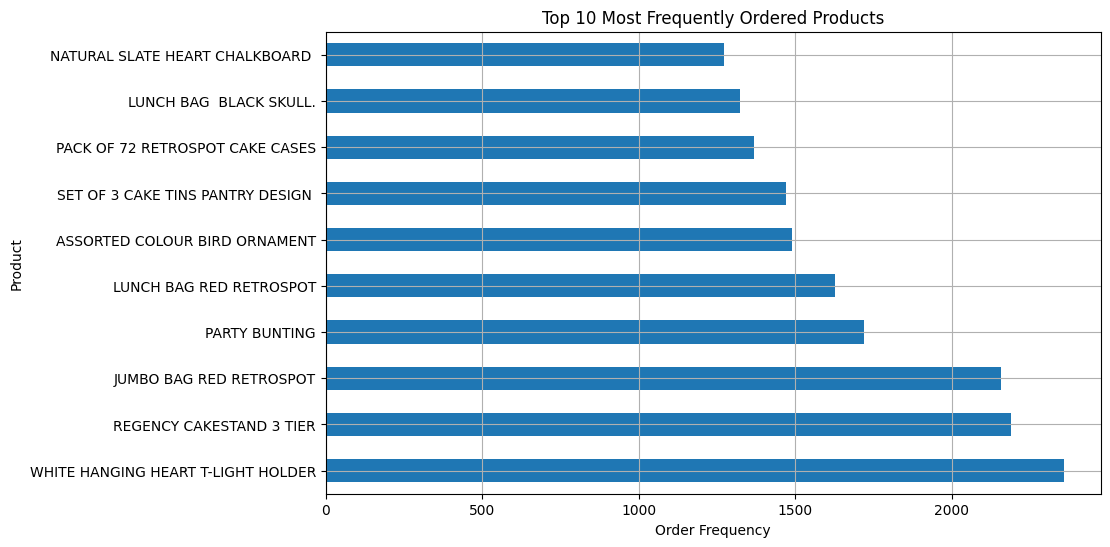

In [156]:
top_10_freq_prod.plot(
    kind='barh',
    grid=True,
    figsize=(10,6)
)
plt.xlabel('Order Frequency')
plt.ylabel('Product')
plt.title('Top 10 Most Frequently Ordered Products')
plt.show()

### Most Frequently Ordered Products Analysis

#### 1. Which product appears in the highest number of orders?

**WHITE HANGING HEART T-LIGHT HOLDER** is the most frequently ordered product, appearing in approximately **2,350 orders**. This indicates widespread popularity across the customer base.

---

#### 2. Which products are ordered most frequently?

Other highly ordered products include:

1. REGENCY CAKESTAND 3 TIER
2. JUMBO BAG RED RETROSPOT
3. PARTY BUNTING
4. LUNCH BAG RED RETROSPOT
5. ASSORTED COLOUR BIRD ORNAMENT

These products consistently appear across a large number of customer orders.

---

#### 3. How does order frequency compare with quantity sold and revenue?

The products with the highest order frequency are not always the same as those with the highest sales quantity or revenue. This highlights different types of product performance:

- Some products generate revenue through higher prices.
- Some products generate demand through high sales volumes.
- Some products appear frequently in customer baskets.

---

#### 4. Which products perform strongly across multiple metrics?

The following products appear in multiple rankings (revenue, quantity sold, and order frequency):

- WHITE HANGING HEART T-LIGHT HOLDER
- REGENCY CAKESTAND 3 TIER
- JUMBO BAG RED RETROSPOT
- PARTY BUNTING
- ASSORTED COLOUR BIRD ORNAMENT

These products represent the strongest-performing items in the retailer's portfolio.

---

#### 5. Business Insight

Products that perform well across revenue, quantity sold, and order frequency should be considered core products. These items drive both customer demand and business revenue and should receive priority in inventory management, marketing campaigns, and promotional activities.

---

### Key Finding

**WHITE HANGING HEART T-LIGHT HOLDER** is the most consistently successful product, appearing among the top-performing products across multiple performance metrics. This suggests strong customer demand, frequent purchasing behavior, and substantial revenue contribution.

# Customer Analysis Section

In [157]:
top_10_valuable_cust = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

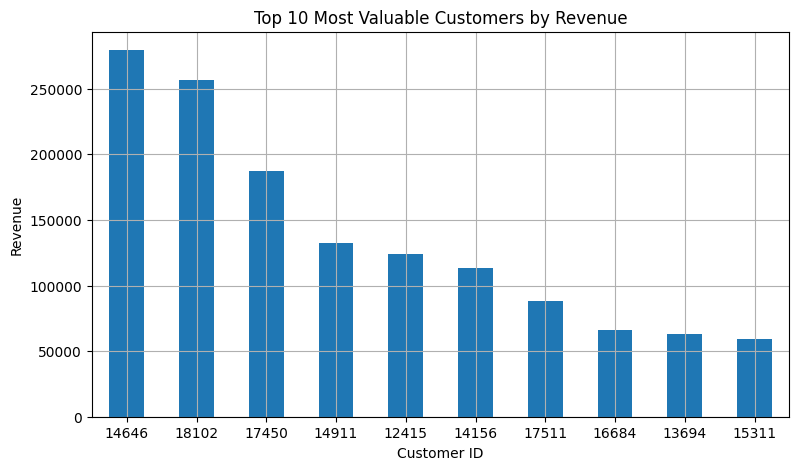

In [158]:
top_10_valuable_cust.plot(
    kind='bar',
    grid=True,
    figsize=(9,5)
)
plt.xticks(rotation=0)
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.title('Top 10 Most Valuable Customers by Revenue')
plt.show()

### Top Customers by Revenue Analysis

#### 1. Who is the highest-value customer?

**CustomerID 14646** is the highest-value customer, generating approximately **£280,000** in revenue during the analysis period.

---

#### 2. Who are the next most valuable customers?

The top revenue-generating customers are:

1. CustomerID 14646
2. CustomerID 18102
3. CustomerID 17450

These customers contribute significantly more revenue than most other customers in the dataset.

---

#### 3. Is revenue concentrated among a small group of customers?

Yes. Revenue appears to be concentrated among a relatively small number of high-value customers. The top three customers generate substantially higher revenue than the remaining customers in the Top 10 ranking.

---

#### 4. Is there a large difference between the highest and lowest customers in the Top 10?

Yes. The highest-value customer generates approximately **£280,000**, while the tenth-ranked customer generates approximately **£60,000**. This substantial difference highlights the importance of retaining high-value customers.

---

#### 5. Business Insight

A relatively small group of customers contributes a significant share of total revenue. Customer retention strategies, personalized marketing campaigns, and loyalty programs targeting these high-value customers could have a substantial impact on overall business performance.

---

### Key Finding

**CustomerID 14646** is the most valuable customer in the dataset, generating approximately **£280,000** in revenue. The analysis indicates that revenue is concentrated among a relatively small number of high-value customers, emphasizing the importance of customer retention and relationship management.

# RFM Customer Segmentation

In [159]:
snapshot_date = pd.Timestamp('2011-12-10')

In [160]:
rfm_table = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()

In [161]:
rfm_table['Recency'] = (snapshot_date - rfm_table['InvoiceDate']).dt.days

In [162]:
freq_table = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

In [163]:
freq_table.rename(columns={'InvoiceNo' : 'Frequency'}, inplace=True)

In [164]:
monetary = df.groupby('CustomerID')['Revenue'].sum().reset_index()

In [165]:
monetary.rename(columns={'Revenue':'Monetary'}, inplace=True)

In [166]:
rfm_table = rfm_table.merge(freq_table, on='CustomerID')

In [167]:
rfm_table = rfm_table.merge(monetary, on='CustomerID')[['CustomerID', 'Recency', 'Frequency', 'Monetary']]

In [168]:
rfm_table['R_Score'] = pd.qcut(
    rfm_table['Recency'],
    q=4,
    labels=[4,3,2,1]
)

In [169]:
rfm_table['F_Score'] = pd.qcut(
    rfm_table['Frequency'].rank(method='first'),
    q=4,
    labels=[1,2,3,4]
)

In [170]:
rfm_table['M_Score'] = pd.qcut(
    rfm_table['Monetary'],
    q=4,
    labels=[1,2,3,4]
)

In [171]:
rfm_table['RFM_Score'] = (
    rfm_table['R_Score'].astype(str) +
    rfm_table['F_Score'].astype(str) +
    rfm_table['M_Score'].astype(str)
)

In [172]:
conditions = [
    (rfm_table['R_Score']==4) & (rfm_table['F_Score']==4) & (rfm_table['M_Score']==4),
    (rfm_table['F_Score']>=3) & (rfm_table['M_Score']>=3),
    (rfm_table['R_Score']==1) & (rfm_table['M_Score']>=3),
    (rfm_table['R_Score']==1) & (rfm_table['F_Score']==1) & (rfm_table['M_Score']==1),
    (rfm_table['R_Score']>=3) & (rfm_table['F_Score']>=2)
]

In [173]:
labels = [
    'Champion',
    'Loyal Customer',
    'At Risk',
    'Lost Customer',
    'Potential Loyalist'
]

In [174]:
rfm_table['Segment'] = np.select(
    conditions,
    labels,
    default='Others'
)

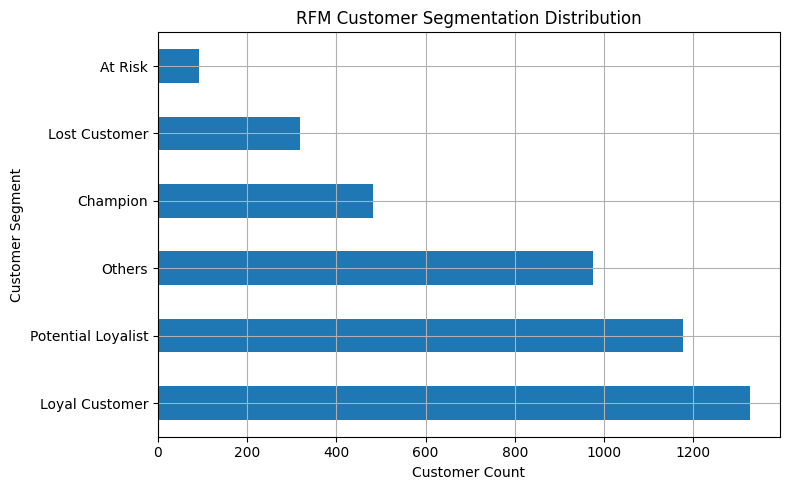

In [175]:
rfm_table['Segment'].value_counts().plot(
    kind='barh',
    grid=True,
    figsize=(8,5)
)

plt.title('RFM Customer Segmentation Distribution')
plt.xlabel('Customer Count')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

### RFM Customer Segmentation Analysis

#### What is RFM Analysis?

RFM (Recency, Frequency, Monetary) analysis is a customer segmentation technique used to identify customer value and purchasing behavior.

- **Recency:** How recently a customer made a purchase.
- **Frequency:** How often a customer makes purchases.
- **Monetary:** How much revenue a customer generates.

Customers were scored on each metric and assigned to customer segments based on their purchasing behavior.

---

#### Segment Distribution

| Segment | Customer Count |
|----------|----------:|
| Loyal Customer | 1,328 |
| Potential Loyalist | 1,177 |
| Champion | 482 |
| Others | 975 |
| Lost Customer | 319 |
| At Risk | 91 |

---

#### Key Findings

##### 1. Loyal Customers represent the largest customer segment

With **1,328 customers**, Loyal Customers form the largest segment in the customer base. These customers purchase frequently and generate significant revenue, making them highly valuable to the business.

---

##### 2. Strong growth opportunity among Potential Loyalists

The dataset contains **1,177 Potential Loyalists**. These customers have shown recent purchasing activity and may become loyal long-term customers through targeted marketing and retention efforts.

---

##### 3. Champions represent the highest-value customers

A total of **482 customers** were classified as Champions. These customers purchase frequently, spend heavily, and have purchased recently. They represent the most valuable customer group.

---

##### 4. Relatively small number of At Risk customers

Only **91 customers** were classified as At Risk. These customers were previously valuable but have not purchased recently. Re-engagement campaigns may help prevent customer churn.

---

##### 5. Lost Customers require reactivation efforts

A total of **319 customers** were classified as Lost Customers. These customers have low purchasing frequency, low spending, and have not purchased recently.

---

#### Business Insight

The customer base demonstrates strong customer loyalty, with a large proportion of customers classified as Loyal Customers, Potential Loyalists, and Champions. Retention programs should focus on maintaining relationships with high-value customers while targeted promotions can be used to reactivate Lost and At Risk customers.

---

### Key Finding

The retailer has a healthy customer base with a strong concentration of Loyal Customers and Potential Loyalists. The relatively small number of At Risk customers suggests good customer retention performance, while Champions represent a valuable group that should receive special attention through loyalty and reward programs.

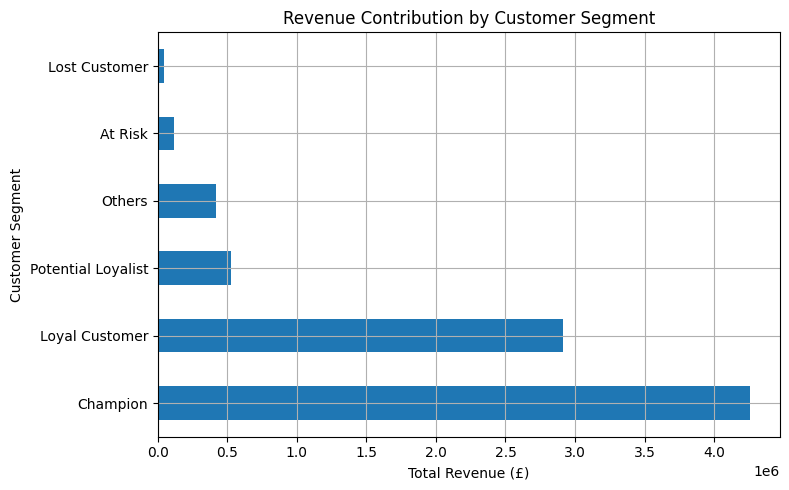

In [176]:
rfm_table.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).plot(
    kind='barh',
    grid=True,
    figsize=(8,5)
)

plt.title('Revenue Contribution by Customer Segment')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

### Revenue Contribution by Customer Segment

#### 1. Which customer segment generates the most revenue?

The **Champion** segment contributes the highest revenue, generating approximately **£4.3 million**. This segment represents the most valuable customers, characterized by recent purchases, high purchase frequency, and high spending levels.

---

#### 2. Which segment is the second-largest revenue contributor?

The **Loyal Customer** segment is the second-largest contributor, generating approximately **£2.9 million** in revenue. These customers purchase frequently and consistently contribute to overall business performance.

---

#### 3. Do all customer segments contribute equally to revenue?

No. Revenue is heavily concentrated among **Champions** and **Loyal Customers**. Together, these two segments account for the majority of total customer revenue.

---

#### 4. Which segments contribute the least revenue?

The **Lost Customer** and **At Risk** segments contribute only a small portion of total revenue. This indicates lower engagement and spending activity from these customer groups.

---

#### 5. Business Insight

The analysis demonstrates that a relatively small group of highly engaged customers generates a substantial portion of total revenue. Retaining Champions and Loyal Customers should be a strategic priority, while targeted campaigns can be used to reactivate At Risk and Lost Customers.

---

### Key Finding

Champions and Loyal Customers are the primary revenue drivers of the business, contributing the vast majority of customer-generated revenue. Maintaining strong relationships with these customer segments can significantly impact long-term business growth and profitability.

# Executive Summary

This project analyzed online retail transactions between December 2010 and December 2011 to identify revenue trends, customer purchasing behavior, product performance, and customer value segments.

## Key Findings

### Revenue Performance
- Total net revenue generated was approximately **£9.73 million**.
- Product returns accounted for approximately **9.4%** of gross revenue.

### Time-Based Trends
- **November 2011** generated the highest monthly revenue.
- **Thursday** was the highest revenue-generating day of the week.
- Revenue peaked around **12 PM**, indicating strong midday purchasing activity.

### Geographic Performance
- The **United Kingdom** dominated sales and revenue generation.
- Among international markets, the strongest performers were:
  - Netherlands
  - EIRE (Ireland)
  - Germany
  - France
  - Australia

### Product Performance
- **REGENCY CAKESTAND 3 TIER** generated the highest revenue.
- **WORLD WAR 2 GLIDERS ASSTD DESIGNS** recorded the highest quantity sold.
- **WHITE HANGING HEART T-LIGHT HOLDER** was the most frequently ordered product.

### Customer Performance
- **CustomerID 14646** generated the highest customer revenue.
- RFM analysis revealed a strong customer base with a large number of Loyal Customers and Potential Loyalists.

### Customer Segmentation
- Champions: 482 customers
- Loyal Customers: 1,328 customers
- Potential Loyalists: 1,177 customers
- Lost Customers: 319 customers
- At Risk Customers: 91 customers

Champions and Loyal Customers contributed the majority of total customer revenue.

# Business Recommendations

## 1. Prioritize High-Performing Products

Increase inventory availability and marketing efforts for:

- REGENCY CAKESTAND 3 TIER
- WHITE HANGING HEART T-LIGHT HOLDER
- JUMBO BAG RED RETROSPOT
- PARTY BUNTING

These products consistently perform well across revenue, quantity sold, and order frequency.

---

## 2. Strengthen Customer Retention

Champions and Loyal Customers contribute the majority of revenue.

Recommended actions:

- Loyalty rewards
- Exclusive offers
- Personalized promotions
- Early access to new products

---

## 3. Convert Potential Loyalists into Loyal Customers

The business has over 1,100 Potential Loyalists.

Recommended actions:

- Targeted email campaigns
- Personalized product recommendations
- Repeat-purchase incentives

---

## 4. Re-engage Lost and At-Risk Customers

Implement customer win-back campaigns through:

- Discount offers
- Limited-time promotions
- Personalized communication

---

## 5. Optimize Marketing Timing

Schedule major promotions during:

- Tuesday to Thursday
- Peak hours between 10 AM and 3 PM

to maximize customer engagement and revenue generation.

---

## 6. Expand Strong International Markets

Focus international marketing and expansion efforts on:

- Netherlands
- EIRE
- Germany
- France
- Australia

These countries demonstrate strong purchasing behavior and revenue contribution.

# Project Conclusion

This project successfully transformed raw online retail transaction data into actionable business insights through data cleaning, exploratory data analysis, customer analysis, and RFM segmentation.

The analysis identified key revenue drivers, customer purchasing patterns, top-performing products, and high-value customer segments. Results show that a relatively small group of highly engaged customers generates a substantial portion of total revenue, while several core products consistently drive both demand and revenue.

The findings highlight opportunities to improve customer retention, optimize marketing efforts, prioritize high-performing products, and expand successful international markets.

Overall, the project demonstrates how data analytics can support data-driven decision-making and help businesses improve operational performance, customer engagement, and long-term profitability.

In [177]:
rfm_table.to_csv('customer_rfm_segmentation.csv', index=False)